In [24]:
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
# from multiclass_functions1 import * # all
# import torch
# from torch import nn, optim
# from torchvision import datasets, transforms
# import numpy as np
# import matplotlib.pyplot as plt
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(DEVICE)

In [25]:
#로컬에서 확장 colab용 환경설정
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
import os
os.makedirs("/content/results", exist_ok=True)
os.makedirs("/content/data", exist_ok=True)
print(os.getcwd())
os.chdir("/content/results") #colab클라우드 런타임에 가상폴더 만들고 이동 

print(os.getcwd())
from multiclass_functions1 import * # * 은 all을 의미
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

/content/results
/content/results
cuda


In [68]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
#new_model_train = False
new_model_train = True
model_type = "MLP"
#model_type = "CNN"
dataset = "MNIST"
#save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}_shuffle.pt"
save_model_path = f"/content/results/{model_type}_{dataset}.pt" #vscode확장 colab용

In [ ]:
def shuffle_pixels(img):
    # 랜덤 시드 고정
    torch.manual_seed(42)

    # (C, H, W) 형태에서 flatten
    flat_img = img.flatten()  # (C * H * W)

    # torch.randperm을 사용하여 랜덤 순서 생성
    perm = torch.randperm(flat_img.shape[0])  # (C * H * W)의 랜덤 인덱스

    # 인덱스를 기반으로 텐서 값 섞기
    shuffled_img = flat_img[perm]  # 섞은 순서로 재배치

    # 원래 형상 복원
    shuffled_img = shuffled_img.reshape(img.shape)  # (C, H, W)

    return shuffled_img

transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 Tensor로 변환 (C, H, W)
    shuffle_pixels, # 픽셀 섞기 함수 적용
])

In [ ]:
#train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
#test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)
train_DS = datasets.MNIST(root = '/content/data', train=True, download=True, transform=transform) #데이터 가져올떄 transform에서 shuffle하는 함수 넣어놔서 섞여서 test_DS변수에 담긴다. 원본데이터를 보고싶을떄는 test_DS.data를 하면된다.
test_DS = datasets.MNIST(root = '/content/data', train=False, download=True, transform=transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

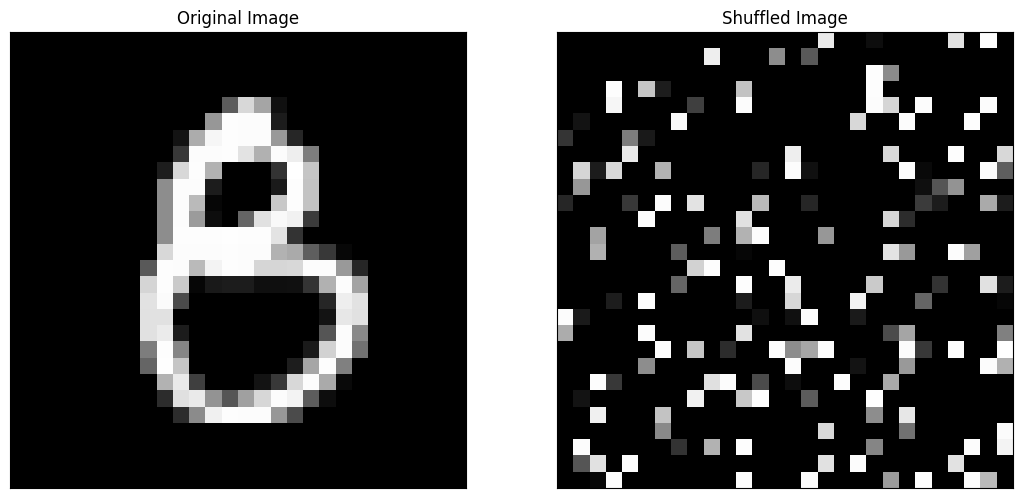

In [ ]:
def show_images_before_after(original, shuffled):

    plt.figure(figsize=(20,15))

    plt.subplot(2,3,1, xticks=[], yticks=[])
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")

    plt.subplot(2,3,2, xticks=[], yticks=[])
    plt.imshow(shuffled, cmap='gray')
    plt.title("Shuffled Image")

# 데이터 하나 가져오기
original_img = test_DS.data[800] #test_DS.data는 데이터셋의 원본 데이터를 가져올수있다.

# 섞은 이미지 생성
shuffled_img = shuffle_pixels(original_img)

# 섞기 전과 후의 이미지 비교
show_images_before_after(original_img, shuffled_img)

In [63]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(28*28, 30),
                                 nn.BatchNorm1d(30),
                                 nn.ReLU(),
                                 nn.Linear(30, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.fcs(x)
        return x
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(1,8,3, padding=1),#흑백 이미지이기떄문에 입력채널 1 #(nn.Conv2d(3,8,3, padding=1)컬러 이미지일때
                                   nn.BatchNorm2d(8),
                                   nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Sequential(nn.Conv2d(8,16,3, padding=1),
                                   nn.BatchNorm2d(16),
                                   nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Sequential(nn.Conv2d(16,32,3, padding=1),
                                   nn.BatchNorm2d(32),
                                   nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        #self.fc = nn.Linear(32*4*4,10) #컬러 이미지일때 차원4차원 개채행렬
        self.fc = nn.Linear(32*3*3,10) #흑백 이미지 일때 차원3차원 개채행렬에서 채널수 1고정

    def forward(self, x):
        x = self.conv1(x)
        x = self.Maxpool1(x)
        x = self.conv2(x)
        x = self.Maxpool2(x)
        x = self.conv3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

In [64]:
model = globals()[model_type]().to(DEVICE)
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

model.eval()
with torch.no_grad():
    print(model(x_batch.to(DEVICE)).shape)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (Maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (Maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=288, out_features=10, bias=True)
)
torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


Epoch: 1, train loss: 0.142
--------------------
Epoch: 2, train loss: 0.048
--------------------
Epoch: 3, train loss: 0.037
--------------------
Epoch: 4, train loss: 0.030
--------------------
Epoch: 5, train loss: 0.026
--------------------


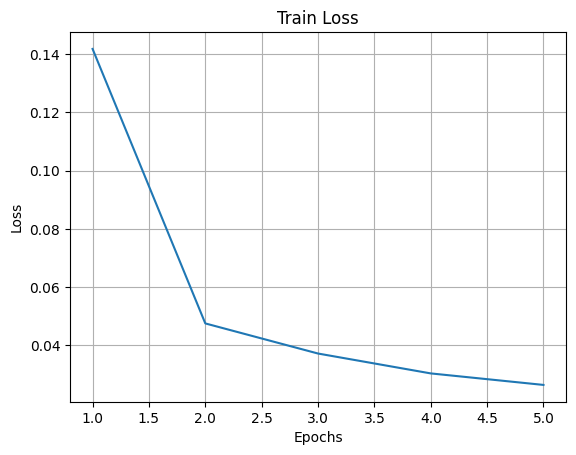

In [65]:
#조건문의 조건 (모델새로 학습)이 True이면 실행(새로학습)
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

    torch.save(model, save_model_path)

    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train Loss")
    plt.grid()

In [66]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

### 실험1. mlp로 이미지픽셀 섞었을떄와 안섞었을떄 acc성능차이
- mlp에서는 이미지 섞어도 섞지않았을떄와 섞었을떄가 별 차이 없음
- 섞었을때 Test accuracy: 9605/10000 (96.0 %)
23920
- 안섞었을떄 Test accuracy: 9678/10000 (96.8 %)
23920
### 실험2. cnn로 이미지픽셀 섞었을떄와 안섞었을때 acc성능차이
- 섞었을떄 Test accuracy: 9445/10000 (94.5 %)
8890
- 안섞었을떄 Test accuracy: 9903/10000 (99.0 %)
8890

### mlp는 크게 성능차이가 없지만 cnn은 성능차이가 난다.

In [67]:
#학습된 모델 그대로 가져와서 test실행
Test(load_model, test_DL)
print(count_params(load_model))

Test accuracy: 9903/10000 (99.0 %)
8890


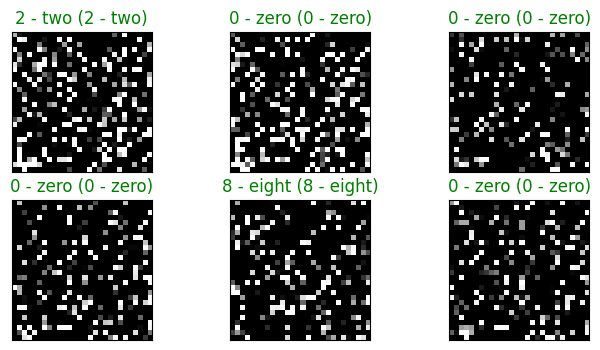

In [39]:
Test_plot(load_model, test_DL)

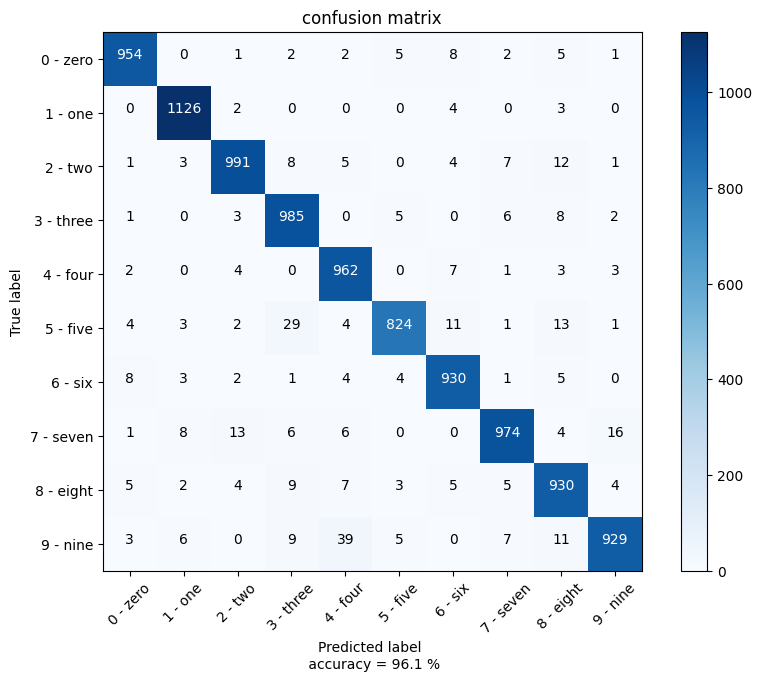

In [ ]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);

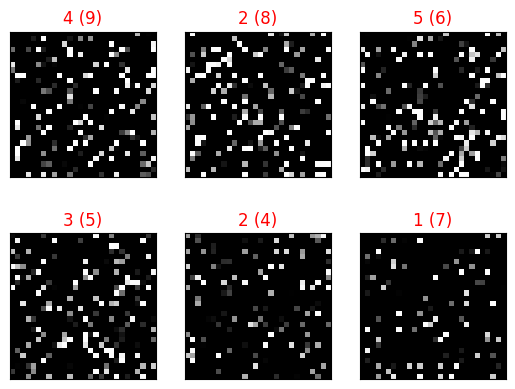

In [ ]:
# 틀린 것만 모아서 보자
cnt = 0
load_model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_DL:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        y_hat = load_model(x_batch)
        pred = y_hat.argmax(dim=1)

        false_idx = pred!=y_batch
        X_false=x_batch[false_idx,...].to("cpu")
        pred_false=pred[false_idx,...].to("cpu")
        Y_false=y_batch[false_idx,...].to("cpu")

        if X_false.shape[0] != 0:
            if cnt==6:
                break
            for i in range(X_false.shape[0]):
                cnt += 1
                pred_class = pred_false[i].item()
                true_class = Y_false[i].item()
                plt.subplot(2,3, cnt, xticks=[], yticks=[])
                plt.imshow(X_false[i,0,...], cmap="gray")
                plt.title(f"{pred_class} ({true_class})",color=("g" if pred_class==true_class else "r"))
                if cnt==6:
                    break